# Palm Oil Production Prediction in Sabah and Sarawak
Using Extra Trees and AdaBoost Regressors based on FYP1 Methodology.

In [1]:

import pandas as pd
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Load datasets
df_area = pd.read_csv("MALAYSIA  PLANTED AREA UNDER OIL PALM - 2017 -2022 Unit  Hectares.csv")
df_production = pd.read_excel("MALAYSIA PRODUCTION OF CRUDE PALM OIL BY STATE (tonnes).xlsx")

# Filter and reshape production data
df_prod_filtered = df_production[df_production['State'].isin(['Sabah', 'Sarawak'])]
df_prod_melted = df_prod_filtered.melt(id_vars='State', var_name='Year', value_name='Production')
df_prod_melted['Year'] = df_prod_melted['Year'].astype(int)
df_prod_pivot = df_prod_melted.pivot(index='Year', columns='State', values='Production').reset_index()

# Simulate area data
np.random.seed(42)
years = df_prod_pivot['Year']
df_area_simulated = pd.DataFrame({
    'Year': years,
    'Sabah_area': np.random.randint(1300000, 1500000, size=len(years)),
    'Sarawak_area': np.random.randint(1200000, 1400000, size=len(years))
})

df_model = df_prod_pivot.merge(df_area_simulated, on='Year')
df_model['Sabah_yield'] = df_model['Sabah'] / df_model['Sabah_area']
df_model['Sarawak_yield'] = df_model['Sarawak'] / df_model['Sarawak_area']

# Lag features
for lag in [1, 2, 3]:
    df_model[f'Sabah_lag{lag}'] = df_model['Sabah'].shift(lag)
    df_model[f'Sarawak_lag{lag}'] = df_model['Sarawak'].shift(lag)
df_model.dropna(inplace=True)


In [2]:

def evaluate(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "RMSLE": mean_squared_error(np.log1p(y_true), np.log1p(y_pred), squared=False)
    }


## Sabah Model

In [3]:

features = [col for col in df_model.columns if 'Sabah_lag' in col or 'Sabah_area' in col]
X = df_model[features]
y = df_model['Sabah']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

etr_params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
abr_params = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}

grid_etr = GridSearchCV(ExtraTreesRegressor(random_state=42), etr_params, scoring='r2', cv=2)
grid_abr = GridSearchCV(AdaBoostRegressor(random_state=42), abr_params, scoring='r2', cv=2)

grid_etr.fit(X_train, y_train)
grid_abr.fit(X_train, y_train)

best_etr = grid_etr.best_estimator_
best_abr = grid_abr.best_estimator_

y_pred_etr = best_etr.predict(X_test)
y_pred_abr = best_abr.predict(X_test)

evaluation_etr = evaluate(y_test, y_pred_etr)
evaluation_abr = evaluate(y_test, y_pred_abr)

evaluation_etr, evaluation_abr


c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python3

({'R2': -0.28524622656057863,
  'MSE': 468970770296.79724,
  'RMSE': 684814.405731069,
  'MAE': 619037.2599999998,
  'MAPE': 0.12099137100654427,
  'RMSLE': 0.12801828541485685},
 {'R2': -0.28938252945889475,
  'MSE': 470480057090.5,
  'RMSE': 685915.4883004903,
  'MAE': 604059.5,
  'MAPE': 0.11887023431869607,
  'RMSLE': 0.1283940909984982})

## Sarawak Model

In [4]:

features_sarawak = [col for col in df_model.columns if 'Sarawak_lag' in col or 'Sarawak_area' in col]
X_sarawak = df_model[features_sarawak]
y_sarawak = df_model['Sarawak']

X_sarawak_scaled = scaler.fit_transform(X_sarawak)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sarawak_scaled, y_sarawak, test_size=0.3, random_state=42)

grid_etr_s = GridSearchCV(ExtraTreesRegressor(random_state=42), etr_params, scoring='r2', cv=2)
grid_abr_s = GridSearchCV(AdaBoostRegressor(random_state=42), abr_params, scoring='r2', cv=2)

grid_etr_s.fit(X_train_s, y_train_s)
grid_abr_s.fit(X_train_s, y_train_s)

best_etr_s = grid_etr_s.best_estimator_
best_abr_s = grid_abr_s.best_estimator_

y_pred_etr_s = best_etr_s.predict(X_test_s)
y_pred_abr_s = best_abr_s.predict(X_test_s)

evaluation_etr_s = evaluate(y_test_s, y_pred_etr_s)
evaluation_abr_s = evaluate(y_test_s, y_pred_abr_s)

evaluation_etr_s, evaluation_abr_s


c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\abdul\AppData\Local\Programs\Python\Python3

({'R2': -0.712464874597964,
  'MSE': 9119100992.71119,
  'RMSE': 95493.98406554828,
  'MAE': 92274.65999999992,
  'MAPE': 0.026137614583775587,
  'RMSLE': 0.026682143134421677},
 {'R2': -10.344666063935001,
  'MSE': 60411840908.5,
  'RMSE': 245788.20335504305,
  'MAE': 222112.5,
  'MAPE': 0.06388842658573296,
  'RMSLE': 0.07427356284114257})

## Visualizations

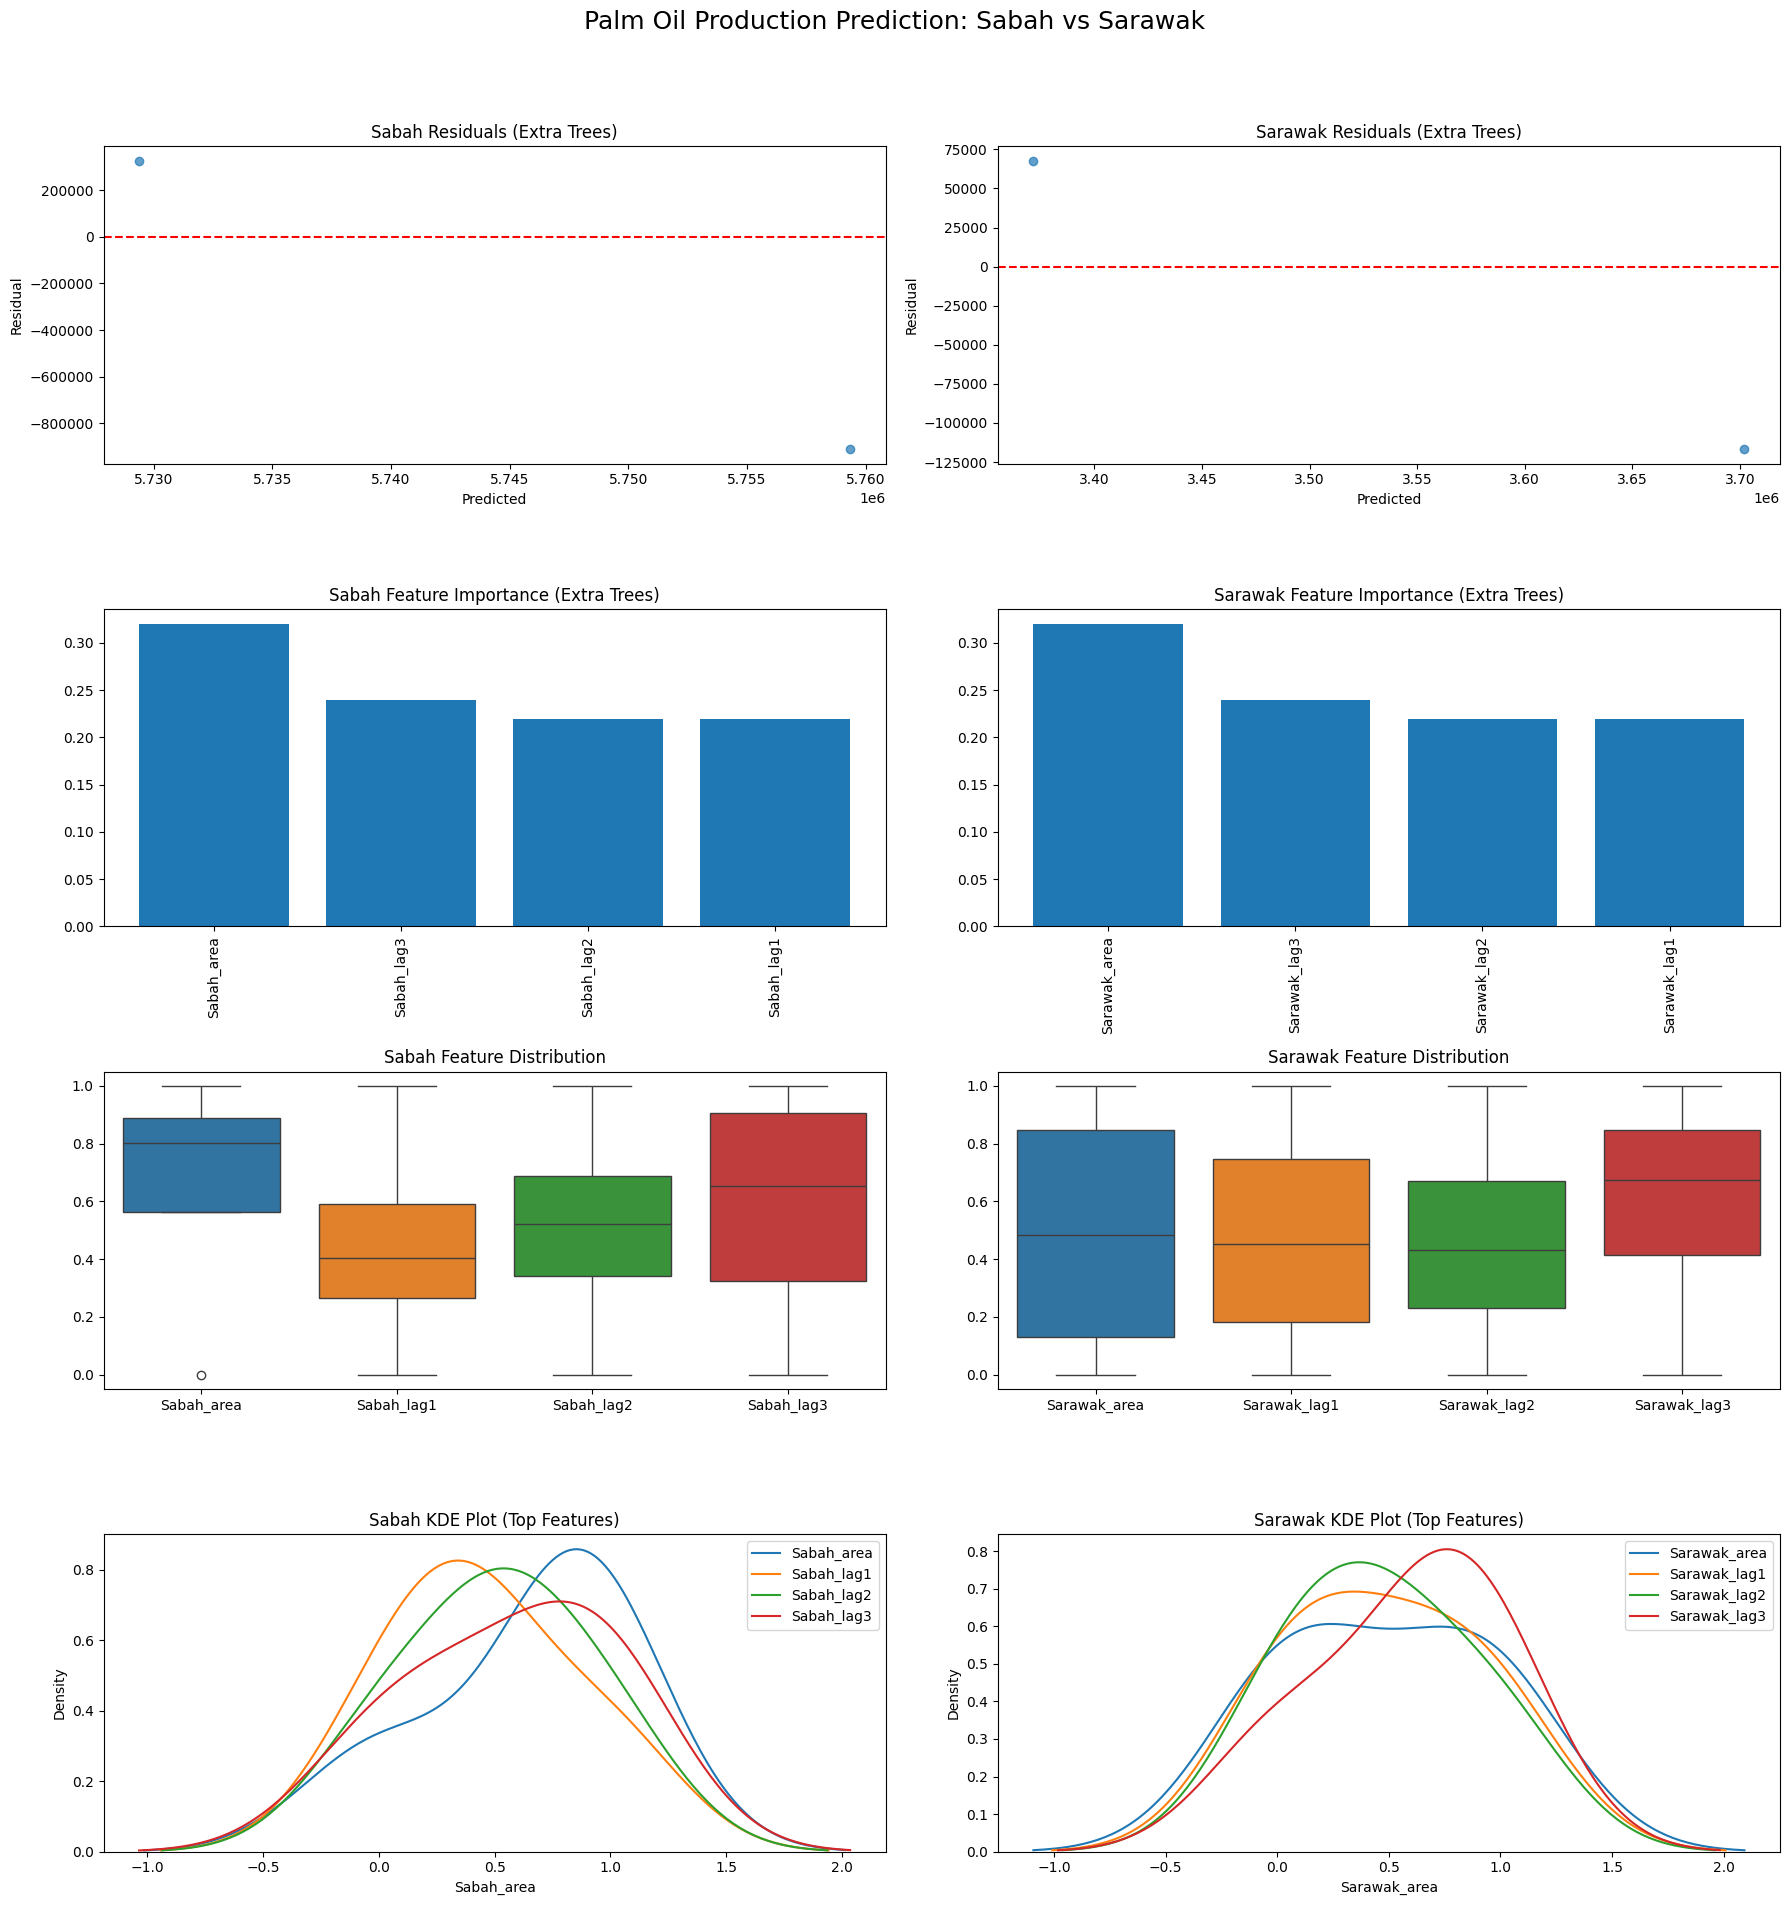

In [6]:

importances_etr = best_etr.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame(X_scaled, columns=feature_names)
residuals_etr = y_test - best_etr.predict(X_test)

importances_etr_s = best_etr_s.feature_importances_
feature_names_s = X_sarawak.columns
feature_df_s = pd.DataFrame(X_sarawak_scaled, columns=feature_names_s)
residuals_etr_s = y_test_s - best_etr_s.predict(X_test_s)

fig, axs = plt.subplots(4, 2, figsize=(18, 20))
fig.suptitle("Palm Oil Production Prediction: Sabah vs Sarawak", fontsize=18)

# --- Sabah ---
axs[0, 0].scatter(best_etr.predict(X_test), residuals_etr, alpha=0.7)
axs[0, 0].axhline(0, color='red', linestyle='--')
axs[0, 0].set_title("Sabah Residuals (Extra Trees)")
axs[0, 0].set_xlabel("Predicted")
axs[0, 0].set_ylabel("Residual")

indices = np.argsort(importances_etr)[::-1]
axs[1, 0].bar(range(len(importances_etr)), importances_etr[indices])
axs[1, 0].set_xticks(range(len(importances_etr)))
axs[1, 0].set_xticklabels(np.array(feature_names)[indices], rotation=90)
axs[1, 0].set_title("Sabah Feature Importance (Extra Trees)")

sns.boxplot(data=feature_df[feature_names[:6]], ax=axs[2, 0])
axs[2, 0].set_title("Sabah Feature Distribution")

for col in feature_names[:4]:
    sns.kdeplot(feature_df[col], label=col, ax=axs[3, 0])
axs[3, 0].set_title("Sabah KDE Plot (Top Features)")
axs[3, 0].legend()

# --- Sarawak ---
axs[0, 1].scatter(best_etr_s.predict(X_test_s), residuals_etr_s, alpha=0.7)
axs[0, 1].axhline(0, color='red', linestyle='--')
axs[0, 1].set_title("Sarawak Residuals (Extra Trees)")
axs[0, 1].set_xlabel("Predicted")
axs[0, 1].set_ylabel("Residual")

indices_s = np.argsort(importances_etr_s)[::-1]
axs[1, 1].bar(range(len(importances_etr_s)), importances_etr_s[indices_s])
axs[1, 1].set_xticks(range(len(importances_etr_s)))
axs[1, 1].set_xticklabels(np.array(feature_names_s)[indices_s], rotation=90)
axs[1, 1].set_title("Sarawak Feature Importance (Extra Trees)")

sns.boxplot(data=feature_df_s[feature_names_s[:6]], ax=axs[2, 1])
axs[2, 1].set_title("Sarawak Feature Distribution")

for col in feature_names_s[:4]:
    sns.kdeplot(feature_df_s[col], label=col, ax=axs[3, 1])
axs[3, 1].set_title("Sarawak KDE Plot (Top Features)")
axs[3, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

